# Recalculating Coastal Upwelling Transport Index (CUTI), Jacox et al., (2018)

For CUTI we need the Ekman net contribution ($Ek_{int}$) + the geostrophic part ($U_{geo}$)

* For the $Ek_{int}$ we integrate the boundaries at every 1 degree perimeter, let the equations be as follow:

\
\begin{aligned}
Q^{(E)}_{E} &= \int_{y_1}^{y_2} U_E(x_E,y)\,dy, = 0 \\
Q^{(W)}_{E} &= - \int_{y_1}^{y_2} U_E(x_W,y)\,dy, \\
Q^{(N)}_{E} &= \int_{x_W}^{x_E} V_E(x,y_2)\,dx, \\
Q^{(S)}_{E} &= - \int_{x_W}^{x_E} V_E(x,y_1)\,dx, \\
Q_{\mathrm{div}}
&= Q^{(E)}_{E} + Q^{(W)}_{E} + Q^{(N)}_{E} + Q^{(S)}_{E}
= \iint\limits_{A} \nabla \!\cdot\! \mathbf{M}_E \, dA, \\
\bar{w}_E
&= \frac{Q_{\mathrm{div}}}{A}
= \frac{1}{\rho\,f}\, \bigl(\nabla \times \boldsymbol{\tau}\bigr)_z .
\end{aligned}

* For geostrophic transport ($U_{geo}$), $\Delta \mathrm{SSH}$ is the difference between the coastal SSH values at the northernmost and southernmost grid points within the 1° segment. The $MLD$ is defined as the width of the Rossby radius of deformation (30 km; R1).

$$
\begin{aligned}
u_{\mathrm{geo}} &= \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}, \\[1ex]
\mathbf{U}_{\mathrm{geo}} &= \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}, \\[1ex]
\text{CUTI} &= U_{\text{ek}} + U_{\text{geo}} \\
&= \frac{\nabla \tau}{\rho_w f} \cdot \hat{k} - \frac{gD}{f} \frac{\partial \eta}{\partial y}.
\end{aligned}
$$

where $g$ is the gravitational acceleration, $D$ is the Ekman layer depth, and $d$ is distance to the coast.

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm 

## Functions

In [2]:
# mask
def coastal_band_mask(ds, var='u10', iterations=10):
    """
    Create a coastal band mask by dilating the coastline edge.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain 2D lat/lon coords and the target variable.
    var : str
        Variable name used to detect land (NaN) vs ocean.
    iterations : int
        Number of dilation steps (~10 km per iteration on a ~10 km grid).

    Returns
    -------
    da_mask : xr.DataArray
        Boolean mask (True inside the coastal band).
    """
    valid2d = np.isfinite(ds[var].mean(dim='time')).values.astype(bool)

    eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
    coast = valid2d & (~eroded)

    band = binary_dilation(coast, structure=np.ones((3, 3)), iterations=iterations) & valid2d

    da_mask = xr.DataArray(
        band,
        dims=('lat', 'lon'),
        coords={'lat': ds['lat'], 'lon': ds['lon']},
    )
    return da_mask

In [3]:
def lat_band_mean(
    f,
    lat_top_start=-4,
    lat_top_end=-17,
):
    """
    Compute the mean of f for successive 1° latitude bands.

    Parameters
    ----------
    f : xarray.DataArray
        Must have a 'lat' dimension (and optionally time/lon/etc.).
    lat_top_start : float or int
        Northern latitude of the first band (e.g. -5).
    lat_top_end : float or int
        Northern latitude of the last band (e.g. -16).

    Returns
    -------
    f_band : xarray.DataArray
        Mean of f for each 1° band, with new dimension 'lat_band'.
        Any other original dimensions (e.g. time) are preserved.
    """

    results = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
        lat_south = lat_north - 1

        # 1° band slice
        f_band = f.sel(lat=slice(lat_south, lat_north))

        # skip bands with no points
        if f_band.sizes.get("lat", 0) == 0:
            continue

        results.append(f_band.mean(dim='lat'))
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    # concat over bands
    f_out = xr.concat(results, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))

    return f_out

In [4]:
## seasonality
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Data

In [5]:
ds = xr.open_dataset('winds_and_components.nc')
ds

<xarray.Dataset> Size: 8GB
Dimensions:            (lon: 602, lat: 542, time: 432)
Coordinates:
  * lon                (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat                (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.951 10.03
  * time               (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    u10                (time, lat, lon) float64 1GB ...
    v10                (time, lat, lon) float64 1GB ...
    tau_alongshore     (time, lat, lon) float64 1GB ...
    Uekman_Crossshore  (time, lat, lon) float64 1GB ...
    Inshore_Uekman     (time, lat, lon) float64 1GB ...
    Uek_geo            (time, lat, lon) float64 1GB ...
    Vek_geo            (time, lat, lon) float64 1GB ...
    f                  (lat) float64 4kB ...

## Uekman or $Ek_{int}$ calculation
* We are using the non-rotated geographical Uekman_geo and Vekman_geo

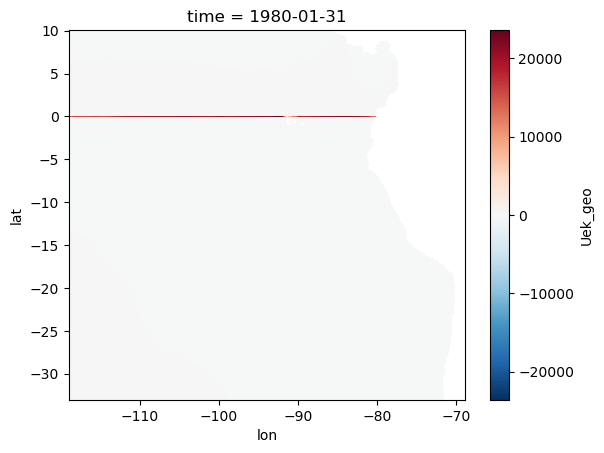

In [6]:
ds.Uek_geo.isel(time=0).plot()

In [7]:
## 111km mask or (1/12)*10*111 km
mask = coastal_band_mask(ds, var='Uek_geo', iterations=1)

wind_coastal = ds.where(mask).sel(lon=slice(-85,None),lat=slice(-20,-4)) 
wind_coastal

<xarray.Dataset> Size: 925MB
Dimensions:            (time: 432, lat: 197, lon: 194)
Coordinates:
  * lon                (lon) float64 2kB -84.95 -84.87 -84.78 ... -68.95 -68.87
  * lat                (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.162 -4.079
  * time               (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    u10                (time, lat, lon) float64 132MB nan nan nan ... nan nan
    v10                (time, lat, lon) float64 132MB nan nan nan ... nan nan
    tau_alongshore     (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Uekman_Crossshore  (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Inshore_Uekman     (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Uek_geo            (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Vek_geo            (time, lat, lon) float64 132MB nan nan nan ... nan nan
    f                  (lat, lon) float64 306kB nan nan nan nan ... nan nan nan

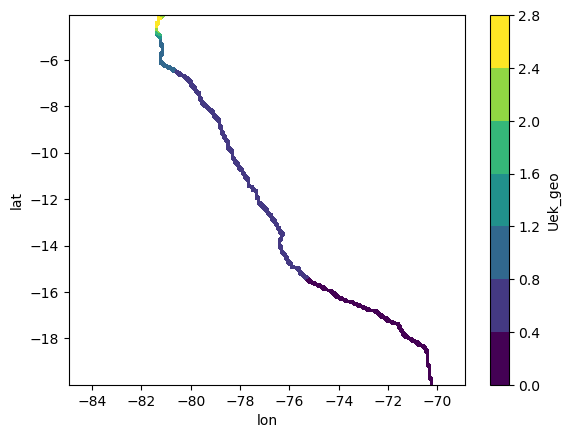

In [8]:
wind_coastal.Uek_geo.std('time').plot.contourf(robust=True)

In [9]:
wind_coastal.lat

<xarray.DataArray 'lat' (lat: 197)> Size: 2kB
array([-19.994865, -19.916554, -19.838205, -19.759817, -19.681391, -19.602926,
       -19.524422, -19.445881, -19.367301, -19.288683, -19.210028, -19.131335,
       -19.052604, -18.973836, -18.89503 , -18.816187, -18.737307, -18.658391,
       -18.579437, -18.500447, -18.42142 , -18.342357, -18.263257, -18.184122,
       -18.10495 , -18.025743, -17.9465  , -17.867221, -17.787907, -17.708557,
       -17.629173, -17.549753, -17.470298, -17.390809, -17.311285, -17.231727,
       -17.152134, -17.072507, -16.992845, -16.91315 , -16.833421, -16.753659,
       -16.673863, -16.594033, -16.514171, -16.434275, -16.354346, -16.274384,
       -16.19439 , -16.114364, -16.034304, -15.954213, -15.87409 , -15.793934,
       -15.713747, -15.633528, -15.553278, -15.472996, -15.392683, -15.312339,
       -15.231964, -15.151558, -15.071121, -14.990654, -14.910157, -14.829629,
       -14.749072, -14.668484, -14.587867, -14.50722 , -14.426544, -14.345838,
       -14.265103, -14.18434 , -14.103547, -14.022725, -13.941875, -13.860997,
       -13.78009 , -13.699156, -13.618193, -13.537202, -13.456184, -13.375139,
       -13.294066, -13.212965, -13.131838, -13.050684, -12.969503, -12.888295,
       -12.807062, -12.725801, -12.644515, -12.563203, -12.481865, -12.400501,
       -12.319112, -12.237697, -12.156258, -12.074793, -11.993303, -11.911789,
       -11.83025 , -11.748687, -11.667099, -11.585488, -11.503852, -11.422193,
       -11.34051 , -11.258804, -11.177074, -11.095321, -11.013546, -10.931747,
       -10.849926, -10.768082, -10.686216, -10.604328, -10.522418, -10.440486,
       -10.358533, -10.276557, -10.194561, -10.112543, -10.030505,  -9.948445,
        -9.866365,  -9.784264,  -9.702143,  -9.620001,  -9.53784 ,  -9.455658,
        -9.373457,  -9.291237,  -9.208997,  -9.126737,  -9.044459,  -8.962162,
        -8.879846,  -8.797511,  -8.715158,  -8.632787,  -8.550398,  -8.467991,
        -8.385566,  -8.303124,  -8.220664,  -8.138187,  -8.055693,  -7.973182,
        -7.890654,  -7.808109,  -7.725549,  -7.642972,  -7.560379,  -7.47777 ,
        -7.395145,  -7.312505,  -7.22985 ,  -7.147179,  -7.064493,  -6.981792,
        -6.899077,  -6.816347,  -6.733603,  -6.650844,  -6.568072,  -6.485285,
        -6.402485,  -6.319671,  -6.236845,  -6.154004,  -6.071151,  -5.988285,
        -5.905407,  -5.822516,  -5.739612,  -5.656697,  -5.573769,  -5.49083 ,
        -5.407879,  -5.324916,  -5.241943,  -5.158958,  -5.075962,  -4.992956,
        -4.909939,  -4.826911,  -4.743873,  -4.660825,  -4.577768,  -4.4947  ,
        -4.411623,  -4.328537,  -4.245441,  -4.162336,  -4.079223])
Coordinates:
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.245 -4.162 -4.079

### Now the $Ek_{int}$

In [10]:
def qdiv_for_band(Uek, Vek,
                  lat_south, lat_north,
                  lon_west=-83, lon_east=-70,
                  delta_y=9250, delta_x=9250, N=12):

    Uek_ = Uek.sel(lat=slice(lat_south, lat_north), lon=slice(lon_west, lon_east))
    Vek_ = Vek.sel(lat=slice(lat_south, lat_north), lon=slice(lon_west, lon_east))

    # Boolean mask of valid ocean cells
    valid = xr.where(np.isfinite(Uek_), 1, 0)
    valid_e = valid.shift(lon=-1)
    valid_w = valid.shift(lon=+1)
    west_mask = (valid == 1) & (valid_w == 0)
    east_mask = (valid == 1) & (valid_e == 0)

    easternmost  = Uek_.where(east_mask)
    westernmost  = Uek_.where(west_mask)
    southernmost = Vek_.isel(lat=0)     # actual southern boundary
    northernmost = Vek_.isel(lat=-1)    # actual northern boundary

    QE = (easternmost.mean('lon')
          .rolling(lat=2, center=False)
          .mean(skipna=True).sum(dim='lat') * delta_y)

    QW = -(westernmost.mean('lon')
           .rolling(lat=2, center=False)
           .mean(skipna=True).sum(dim='lat') * delta_y)

    QN = (northernmost
          .rolling(lon=2, center=False)
          .mean(skipna=True).sum(dim='lon') * delta_x)

    QS = -(southernmost
           .rolling(lon=2, center=False)
           .mean(skipna=True).sum(dim='lon') * delta_x)

    Qdiv = (QW + QS + QN) / (delta_x * (N - 1))
    return Qdiv

In [11]:
step = 0.25# or 0.25

lat_top_start = -4.0
lat_top_end   = -17.0

results = []
lat_band_centers = []

lat_north = lat_top_start
while lat_north > lat_top_end:
    lat_south = lat_north - step

    Qdiv_band = qdiv_for_band(
        wind_coastal.Uek_geo, wind_coastal.Vek_geo,
        lat_south=lat_south, lat_north=lat_north,
        lon_west=-83, lon_east=-70,
        delta_y=9250, delta_x=9250, N=12
    )

    results.append(Qdiv_band)
    lat_band_centers.append(0.5 * (lat_south + lat_north))
    lat_north -= step

Qdiv_all = xr.concat(results, dim='lat_band')
U_ek = Qdiv_all.assign_coords(lat_band=lat_band_centers)

In [12]:
U_ek

<xarray.DataArray (lat_band: 52, time: 432)> Size: 180kB
array([[0.3959474 , 0.21578988, 0.14286186, ..., 0.60368037, 0.68631542,
        0.51884118],
       [0.89167051, 0.58401093, 0.3721568 , ..., 1.4783926 , 1.56163458,
        1.27484481],
       [0.65771107, 0.41530793, 0.27551345, ..., 1.15772791, 1.24664465,
        1.00289893],
       ...,
       [0.06004922, 0.00949714, 0.00840869, ..., 0.11891431, 0.11270119,
        0.10943112],
       [0.1496484 , 0.11382964, 0.10122308, ..., 0.25347511, 0.23867545,
        0.2105202 ],
       [0.3373202 , 0.36437435, 0.34821231, ..., 0.52714695, 0.49263126,
        0.43180695]])
Coordinates:
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 416B -4.125 -4.375 -4.625 ... -16.62 -16.88

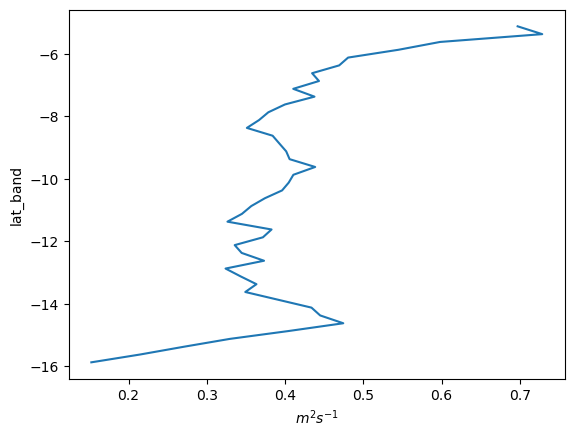

In [15]:
(U_ek).mean('time').rolling(lat_band=5).mean().sel(lat_band=slice(-5,-16)).rename('$m^{2}s^{-1}$').plot(y='lat_band')
# (U_ek).sel(lat_band=slice(-4,-17)).mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')

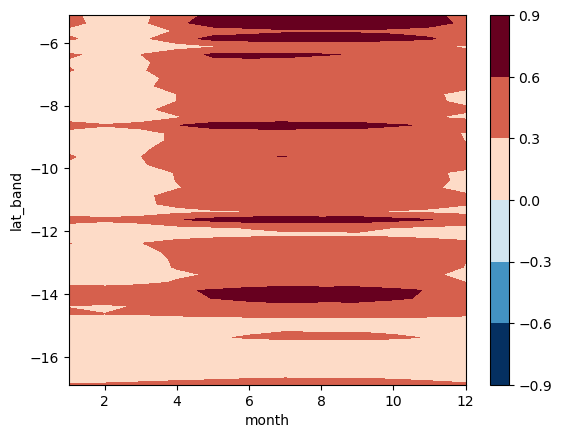

In [14]:
seasonality(U_ek).sel(lat_band=slice(-5,-17)).plot.contourf(x='month')